# Unsupervised Learning on Graphs

This notebook explores a specific type of unsupervised representation learning technique with graph-structured data. In particular this will be a **contrastive learning** model, where an encoder is trained to be contrastive and distinguish between representations that are dependent on each other and those that are not.

A possible approach to obtain such an encoder is to train it to maximise the **local mutual information** between a global representation of the graph and its node representations. 

In [463]:
import torch
import torch.nn as nn
import torch_geometric.nn as pygnn
import torch.nn.functional as F

For our encoder we will use a polynomial filter introduced by Defferrard et. al. 

$$
\begin{aligned}
H &= \sum_{k=1}^{K}Z^{(k)}\Theta^{(k)} \\ 
Z^{(1)} & = X \\
Z^{(2)} & = \tilde{L}X \\
Z^{(k)} & = 2\tilde{L}Z^{(k-1)} - Z^{(k-2)}
\end{aligned}
$$
where $\tilde{L}=2L/\lambda_{\text{max}} - I$ is a Laplacian matrix scaled by its largest eigenvalue. Because this architecture uses Chebyshev polynomials, it is commonly known as *ChebNet*. PyG already provides an implementation of the base convolution for us. 

Hyperparameter $K$ is the order of the polynomial and directly controls the receptive field of the filter. 

In [464]:
class ChebNet(nn.Module):

    def __init__(self, in_channels, hidden_channels, out_channels, **kwargs):
        super().__init__(**kwargs)


        self.encoder = nn.Sequential(
            nn.Linear(in_features=in_channels,out_features=hidden_channels),
            nn.PReLU()
        )

        self.convs = pygnn.ChebConv(in_channels=hidden_channels, out_channels=hidden_channels, K=5)

        self.decoder = nn.Sequential(
            torch.nn.BatchNorm1d(hidden_channels, momentum=0.01),
            nn.Linear(in_features=hidden_channels,out_features=out_channels),
            nn.PReLU(),
        )

        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x, edge_index):
        x = self.encoder(x)
        x = self.dropout(x)
        x = self.convs(x, edge_index)
        x = self.decoder(x)

        return x
    
    def get_negative_example(self, x):
        # Shuffles along the node dimension (node i gets features of j)
        n = x.shape[-2]
        perm = torch.randperm(n)
        x_ = x.clone()
        return x_[perm]

In [465]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

embeddings = Planetoid(root=f'data/', name='cora', transform=NormalizeFeatures())

In [445]:
graph = embeddings[0]

In [466]:
model = ChebNet(in_channels=1433, hidden_channels=512, out_channels=512)

In [467]:
class Discriminator(nn.Module):
    def __init__(self, dim):
        super(Discriminator, self).__init__()
        self.fn = nn.Bilinear(dim, dim, 1)

    def forward(self, h, c):
        c_x = c.expand_as(h).contiguous()
        sc = self.fn(h, c_x).squeeze(1)
        return sc

In [468]:
disc = Discriminator(dim=512)

In [469]:
def get_graph_summary(x):
    return x.mean(dim=-2)

In [470]:
def contrastive_loss(H, H_tilde, s, D: Discriminator):
    embeddings = torch.cat((H, H_tilde), dim=0)
    return F.binary_cross_entropy_with_logits(
        D(embeddings, s),
        torch.cat((torch.ones(H.shape[0], device=s.device), 
                   torch.zeros(H.shape[0], device=s.device)))
    )

In [471]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
disc = disc.to(device)
graph = graph.to(device)

In [472]:
optim = torch.optim.Adam([{'params': model.parameters(), 'lr': 0.0005},
                          {'params': disc.parameters(), 'lr': 0.001}])

In [473]:
epochs = 750
losses = []
for e in range(epochs):
    model.train()
    disc.train()
    optim.zero_grad()

    h = model(graph.x, graph.edge_index)
    h_tilde = model(model.get_negative_example(graph.x), graph.edge_index)

    s = get_graph_summary(h)

    loss = contrastive_loss(H=h, H_tilde=h_tilde, s=s, D=disc)

    loss.backward()
    optim.step()
    if e %50 == 0:
        print(e, loss.item())
    losses.append(loss.item())

0 0.7748803496360779
50 0.683491587638855
100 0.10324833542108536
150 0.0073988004587590694
200 0.0010954579338431358
250 0.0004240839625708759
300 0.000485454365843907
350 0.000473607680760324
400 0.00011082999117206782
450 0.0001394330756738782
500 0.00018553789413999766
550 8.201904711313546e-05
600 4.4130312744528055e-05
650 0.0001179943501483649
700 5.6330911320401356e-05


In [474]:
embeddings = model(graph.x, graph.edge_index).detach()
train_embs = embeddings[graph.train_mask]
train_labels = graph.y[graph.train_mask]

val_embs = embeddings[graph.val_mask]
val_labels = graph.y[graph.val_mask]

In [476]:
import matplotlib.pyplot as plt

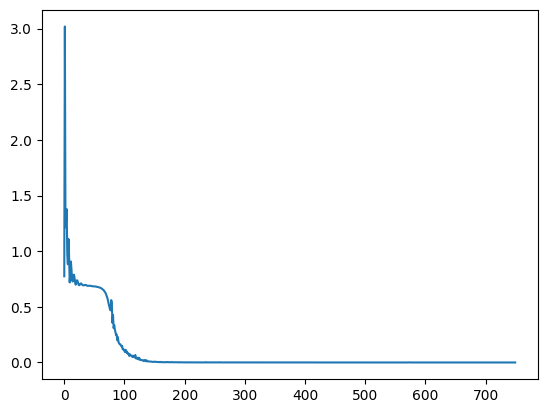

In [477]:
plt.plot(losses)

In [494]:
class LinearClassifier(nn.Module):
    def __init__(self, features, classes):
        super().__init__()
        self.lin = nn.Linear(features, classes)


    def forward(self, x):
        return self.lin(x)
    
classifier = LinearClassifier(512,7)
classifier = classifier.to(device)

In [495]:
opt = torch.optim.Adam(classifier.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

In [496]:
for epoch in range(20):
    classifier.train()
    opt.zero_grad()

    logits = classifier(train_embs)

    loss = loss_fn(logits, train_labels)
    loss.backward()
    opt.step()

    print(loss.item())

2.0959534645080566
1.40798020362854
1.2343528270721436
1.07794988155365
0.8845263719558716
0.7620189189910889
0.7089029550552368
0.6545941233634949
0.5945106148719788
0.5472972393035889
0.510287344455719
0.47644272446632385
0.43915611505508423
0.4015388786792755
0.3702031373977661
0.3448176681995392
0.3221735954284668
0.3009527623653412
0.2803819179534912
0.2600591778755188


In [497]:
(torch.argmax(torch.nn.functional.softmax(classifier(val_embs), dim=-1),dim=-1) == val_labels).to(torch.float32).mean()

tensor(0.7100, device='cuda:0')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch

embeddings = model(graph.x, graph.edge_index).cpu().detach().numpy()
labels = graph.y.cpu().detach().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, early_exaggeration=12, n_iter=2000)
data_2d = tsne.fit_transform(embeddings)


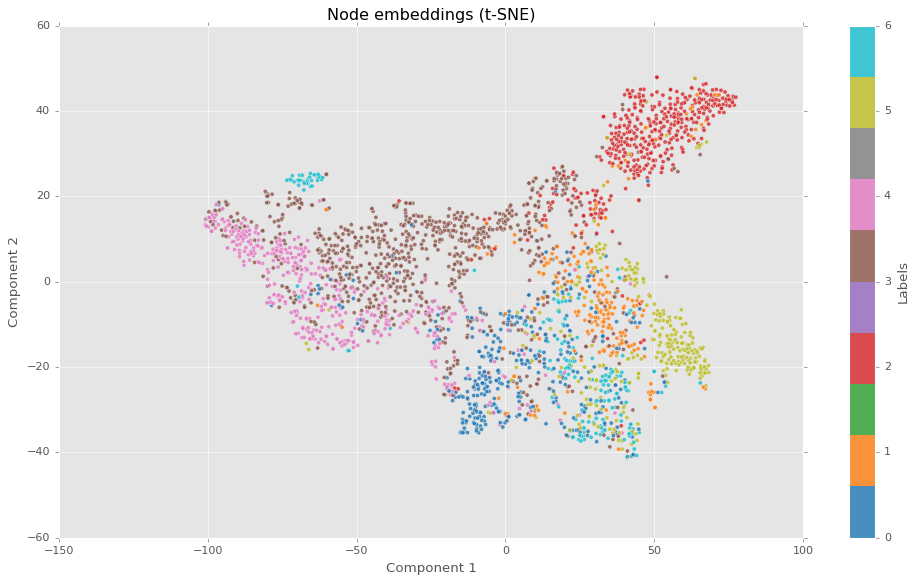

In [511]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(15, 8))
scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap='tab10', s=15, alpha=0.8)
plt.colorbar(scatter, label="Labels")
plt.title("Node embeddings (t-SNE)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()
